# 🏠 Egyptian House Price Predictor
### End-to-End Machine Learning Pipeline: From Raw Data to Deployed ML Application
**Author:** AI Pair Programming | **Target Market:** Egyptian Real Estate Market 🇪🇬

---
### 📌 Overview & Objectives
This notebook implements a complete, production-grade Machine Learning pipeline for predicting house and apartment prices across Egypt.
The workflow covers:
1. **Data Understanding & Inspection**: Examining raw listings, data types, missing values, and anomalies.
2. **Data Cleaning & Feature Engineering**: Standardizing pricing, extracting square meters, parsing multi-level locations (Compound, City, Governorate), and detecting key amenities.
3. **Exploratory Data Analysis (EDA)**: Visualizing distributions, geographic pricing heatmaps, and property characteristics.
4. **Machine Learning Pipelines**: Preprocessing pipelines with Target Transformation (log-scaling) and Column Transformers.
5. **Multi-Model Comparison**: Benchmarking **Linear Regression**, **Random Forest**, **LightGBM**, and **XGBoost**.
6. **Model Serialization**: Saving the best performing pipeline for serving via FastAPI and our Full-Stack Web Application.



## 1. Imports & Environment Setup
We import core scientific computing, data manipulation, visualization, and machine learning libraries.



In [1]:
import os
import re
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn & Gradient Boosting Models
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 110

print("✅ All libraries loaded successfully!")



✅ All libraries loaded successfully!



## 2. Data Understanding & Initial Inspection
In this phase, we load the raw real estate listings dataset collected from Egyptian property platforms and examine its structure.



In [2]:
# Locate and load the raw dataset
csv_candidates = [
    "backend/data/egypt_real_estate_listings.csv",
    "../data/egypt_real_estate_listings.csv",
    "data/egypt_real_estate_listings.csv",
    "egypt_real_estate_listings.csv"
]
data_path = next((p for p in csv_candidates if os.path.exists(p)), None)
if not data_path:
    raise FileNotFoundError("Could not find egypt_real_estate_listings.csv")

df_raw = pd.read_csv(data_path)
print(f"📊 Dataset successfully loaded from: {data_path}")
print(f"🔹 Total Rows (Listings): {df_raw.shape[0]:,}")
print(f"🔹 Total Columns (Features): {df_raw.shape[1]}")
print("-" * 60)
print("Preview of first 5 records:")
display_df = df_raw.head(5)
print(display_df[['price', 'location', 'type', 'size', 'bedrooms', 'bathrooms']])



📊 Dataset successfully loaded from: backend/data/egypt_real_estate_listings.csv
🔹 Total Rows (Listings): 19,924
🔹 Total Columns (Features): 11
------------------------------------------------------------
Preview of first 5 records:
        price  ... bathrooms
0   8,000,000  ...         1
1  25,000,000  ...         4
2  15,135,000  ...         2
3  12,652,000  ...         2
4  45,250,000  ...         7

[5 rows x 6 columns]



In [3]:
# Inspect data types and missing value counts
info_summary = pd.DataFrame({
    'Data Type': df_raw.dtypes,
    'Non-Null Count': df_raw.notnull().sum(),
    'Null Count': df_raw.isnull().sum(),
    'Null %': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print("📋 Column Data Types & Missingness:")
print(info_summary)

duplicate_count = df_raw.duplicated().sum()
print(f"\n🔹 Duplicate records count: {duplicate_count:,}")



📋 Column Data Types & Missingness:
               Data Type  Non-Null Count  Null Count  Null %
url                  str           19924           0    0.00
price                str           19385         539    2.71
description          str           19846          78    0.39
location             str           19833          91    0.46
type                 str           19847          77    0.39
size                 str           19847          77    0.39
bedrooms             str           19780         144    0.72
bathrooms            str           19784         140    0.70
available_from       str           19261         663    3.33
payment_method       str           19383         541    2.72
down_payment         str            5445       14479   72.67

🔹 Duplicate records count: 0



## 3. Data Cleaning & Feature Engineering (Justified)
Raw real estate web scrapes contain messy text, missing data, and noise. Here we apply systematic cleaning:
1. **Price Standardization**: Clean commas, extract numeric values, and eliminate invalid/zero prices.
2. **Area Extraction (`area_sqm`)**: Parse square meter values from the `size` text column.
3. **Bedrooms & Bathrooms**: Extract numeric integers, cap extreme unrealistic outliers.
4. **Hierarchical Location Splitting**: The `location` field contains comma-separated values (`Compound, City, Governorate`). We parse them into distinct structured features.
5. **Amenity Flag Mining**: Extract high-value signals from `description` and listing metadata (`has_pool`, `has_garden`, `has_sea_view`, `is_furnished`, `is_fully_finished`, `has_maid_room`).
6. **Outlier Filtering**: Drop records with impossible dimensions (< 20 sqm or > 10,000 sqm) or extreme price anomalies.



In [4]:
df = df_raw.copy()

# 1. Clean Price
def parse_price(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).replace(',', '').strip()
    match = re.search(r'(\d+(?:\.\d+)?)', val_str)
    return float(match.group(1)) if match else np.nan

df['price_clean'] = df['price'].apply(parse_price)

# 2. Extract Area in SQM
def parse_sqm(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).replace(',', '').strip()
    match = re.search(r'(\d+(?:\.\d+)?)', val_str)
    return float(match.group(1)) if match else np.nan

df['area_sqm'] = df['size'].apply(parse_sqm)

# 3. Clean Bedrooms and Bathrooms
def parse_numeric(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip()
    match = re.search(r'(\d+)', val_str)
    return float(match.group(1)) if match else np.nan

df['bedrooms_clean'] = df['bedrooms'].apply(parse_numeric)
df['bathrooms_clean'] = df['bathrooms'].apply(parse_numeric)

# 4. Location Parsing (Compound, City, Governorate)
def parse_location(loc):
    if pd.isna(loc):
        return pd.Series(['Unknown', 'Unknown', 'Unknown'])
    parts = [p.strip() for p in str(loc).split(',') if p.strip()]
    if len(parts) == 1:
        return pd.Series([parts[0], parts[0], parts[0]])
    elif len(parts) == 2:
        return pd.Series([parts[0], parts[0], parts[1]])
    else:
        compound = parts[0]
        city = parts[-2]
        governorate = parts[-1]
        return pd.Series([compound, city, governorate])

df[['compound', 'city', 'governorate']] = df['location'].apply(parse_location)

# Keep top 100 compounds to avoid high-cardinality explosion
top_compounds = df['compound'].value_counts().nlargest(100).index
df['compound'] = df['compound'].where(df['compound'].isin(top_compounds), 'Other')

# 5. Amenity Feature Extraction from Description
desc = df['description'].fillna('').astype(str).str.lower()
df['has_pool'] = desc.str.contains('pool|حمام سباحة|مسبح', case=False, regex=True).astype(int)
df['has_garden'] = desc.str.contains('garden|حديقة', case=False, regex=True).astype(int)
df['has_sea_view'] = desc.str.contains('sea view|lake|بحيرة|فيو البحر|مطل على البحر', case=False, regex=True).astype(int)
df['is_furnished'] = desc.str.contains('furnished|مفروش', case=False, regex=True).astype(int)
df['is_fully_finished'] = desc.str.contains('fully finished|تشطيب كامل|الترا سوبر لوكس|سوبر لوكس', case=False, regex=True).astype(int)
df['has_maid_room'] = df['bedrooms'].astype(str).str.contains('maid', case=False, na=False).astype(int)

# Payment method
df['payment_method'] = df['payment_method'].fillna('Cash')
df['has_down_payment'] = df['down_payment'].notna().astype(int)

# Standardize Property Type
def clean_type(t):
    if pd.isna(t):
        return 'Apartment'
    t_str = str(t).strip()
    if 'Apartment' in t_str or 'شقة' in t_str:
        return 'Apartment'
    elif 'Villa' in t_str or 'فيلا' in t_str:
        return 'Villa'
    elif 'Chalet' in t_str or 'شاليه' in t_str:
        return 'Chalet'
    elif 'Duplex' in t_str or 'دوبلكس' in t_str:
        return 'Duplex'
    elif 'Penthouse' in t_str or 'بنتهاوس' in t_str:
        return 'Penthouse'
    elif 'Townhouse' in t_str or 'تاون هاوس' in t_str:
        return 'Townhouse'
    elif 'Twin House' in t_str:
        return 'Twin House'
    return t_str

df['type_clean'] = df['type'].apply(clean_type)

# 6. Apply Domain & Outlier Filtering
# Keep properties with price >= 200,000 EGP and <= 150,000,000 EGP
# Keep area between 25 sqm and 2,500 sqm
filter_mask = (
    df['price_clean'].notna() &
    (df['price_clean'] >= 200_000) &
    (df['price_clean'] <= 150_000_000) &
    df['area_sqm'].notna() &
    (df['area_sqm'] >= 25) &
    (df['area_sqm'] <= 2_500) &
    (df['bedrooms_clean'].between(1, 12, inclusive='both') | df['bedrooms_clean'].isna()) &
    (df['bathrooms_clean'].between(1, 10, inclusive='both') | df['bathrooms_clean'].isna())
)

df_clean = df[filter_mask].copy()

# Fill missing bedroom/bathroom with medians
df_clean['bedrooms_clean'] = df_clean['bedrooms_clean'].fillna(df_clean['bedrooms_clean'].median())
df_clean['bathrooms_clean'] = df_clean['bathrooms_clean'].fillna(df_clean['bathrooms_clean'].median())

# Target column name
df_clean['price'] = df_clean['price_clean']

# Save cleaned dataset
os.makedirs("backend/data", exist_ok=True)
df_clean.to_csv("backend/data/cleaned_dataset.csv", index=False)

print(f"✅ Data Cleaning Complete!")
print(f"🔹 Rows before cleaning: {len(df_raw):,}")
print(f"🔹 Rows after cleaning & outlier removal: {len(df_clean):,} ({len(df_clean)/len(df_raw)*100:.1f}% retained)")
print(f"🔹 Cleaned dataset saved to: backend/data/cleaned_dataset.csv")



✅ Data Cleaning Complete!
🔹 Rows before cleaning: 19,924
🔹 Rows after cleaning & outlier removal: 14,279 (71.7% retained)
🔹 Cleaned dataset saved to: backend/data/cleaned_dataset.csv



## 4. Exploratory Data Analysis (EDA)
We explore key pricing drivers in the Egyptian real estate market through insightful visualizations.



📌 Price Summary (EGP):
   Median Price : 8,400,000 EGP
   Mean Price   : 10,389,328 EGP
   25th - 75th %: 5,200,000 to 13,500,000 EGP



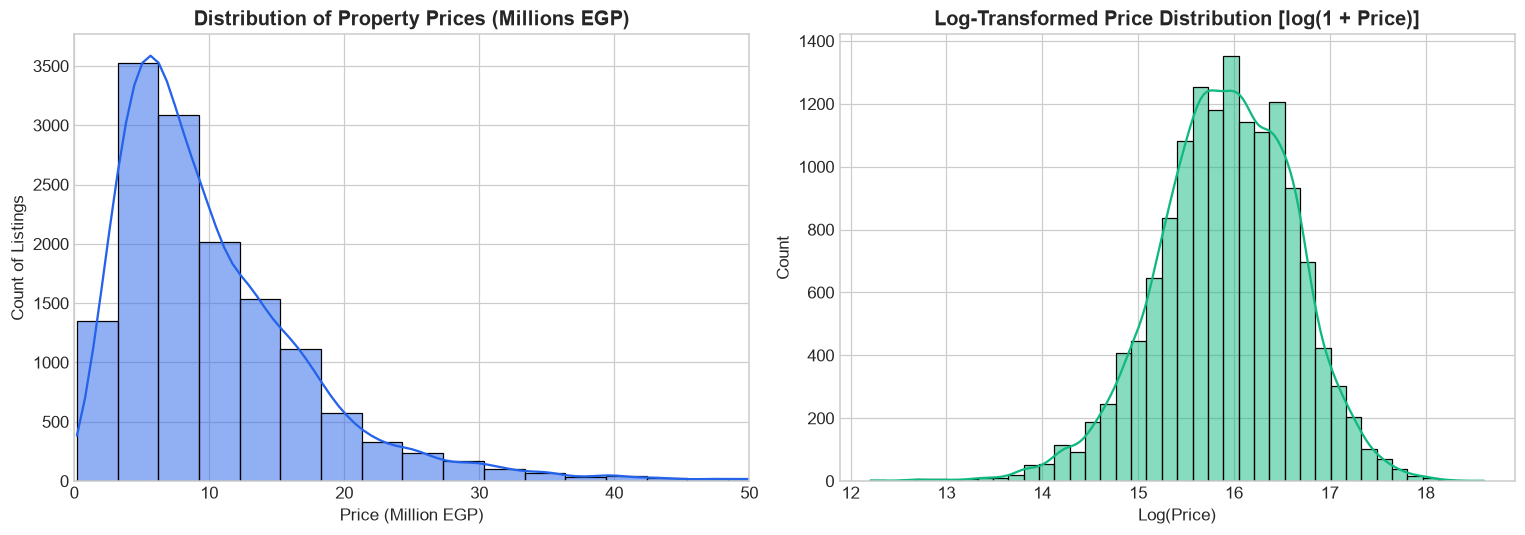

In [5]:
# Plot 1: Target Price Distribution (Raw vs Log Scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Price Distribution (in Millions EGP)
sns.histplot(df_clean['price'] / 1e6, bins=40, kde=True, color='#2563EB', ax=axes[0])
axes[0].set_title("Distribution of Property Prices (Millions EGP)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Price (Million EGP)")
axes[0].set_ylabel("Count of Listings")
axes[0].set_xlim(0, 50)

# Log-transformed Price
sns.histplot(np.log1p(df_clean['price']), bins=40, kde=True, color='#10B981', ax=axes[1])
axes[1].set_title("Log-Transformed Price Distribution [log(1 + Price)]", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Log(Price)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"📌 Price Summary (EGP):")
print(f"   Median Price : {df_clean['price'].median():,.0f} EGP")
print(f"   Mean Price   : {df_clean['price'].mean():,.0f} EGP")
print(f"   25th - 75th %: {df_clean['price'].quantile(0.25):,.0f} to {df_clean['price'].quantile(0.75):,.0f} EGP")



💡 Pearson Correlation between Area and Price: 0.338 (Strong Positive Relationship)



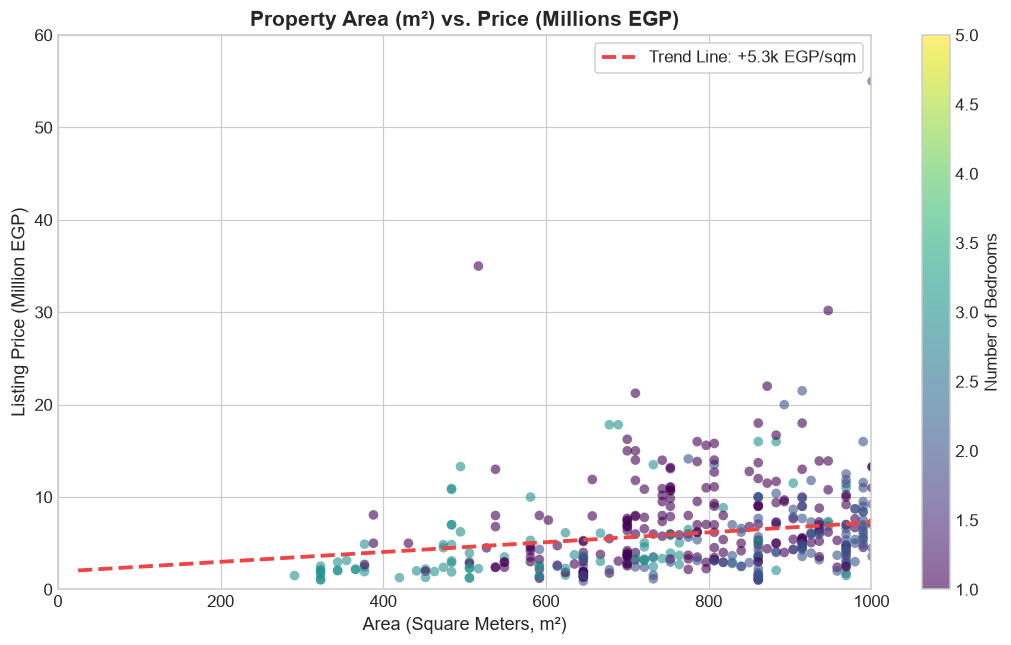

In [6]:
# Plot 2: Property Area vs Price
plt.figure(figsize=(10, 6))

sample_eda = df_clean.sample(min(3000, len(df_clean)), random_state=42)
scatter = plt.scatter(
    sample_eda['area_sqm'],
    sample_eda['price'] / 1e6,
    c=sample_eda['bedrooms_clean'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='none',
    s=40
)
cbar = plt.colorbar(scatter)
cbar.set_label('Number of Bedrooms', fontsize=11)

# Fit linear trendline
m, b = np.polyfit(sample_eda['area_sqm'], sample_eda['price'] / 1e6, 1)
x_vals = np.linspace(25, 1000, 100)
plt.plot(x_vals, m * x_vals + b, color='#EF4444', linewidth=2.5, linestyle='--', label=f'Trend Line: +{m*1000:.1f}k EGP/sqm')

plt.title("Property Area (m²) vs. Price (Millions EGP)", fontsize=14, fontweight='bold')
plt.xlabel("Area (Square Meters, m²)", fontsize=12)
plt.ylabel("Listing Price (Million EGP)", fontsize=12)
plt.xlim(0, 1000)
plt.ylim(0, 60)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

corr_area_price = df_clean['area_sqm'].corr(df_clean['price'])
print(f"💡 Pearson Correlation between Area and Price: {corr_area_price:.3f} (Strong Positive Relationship)")



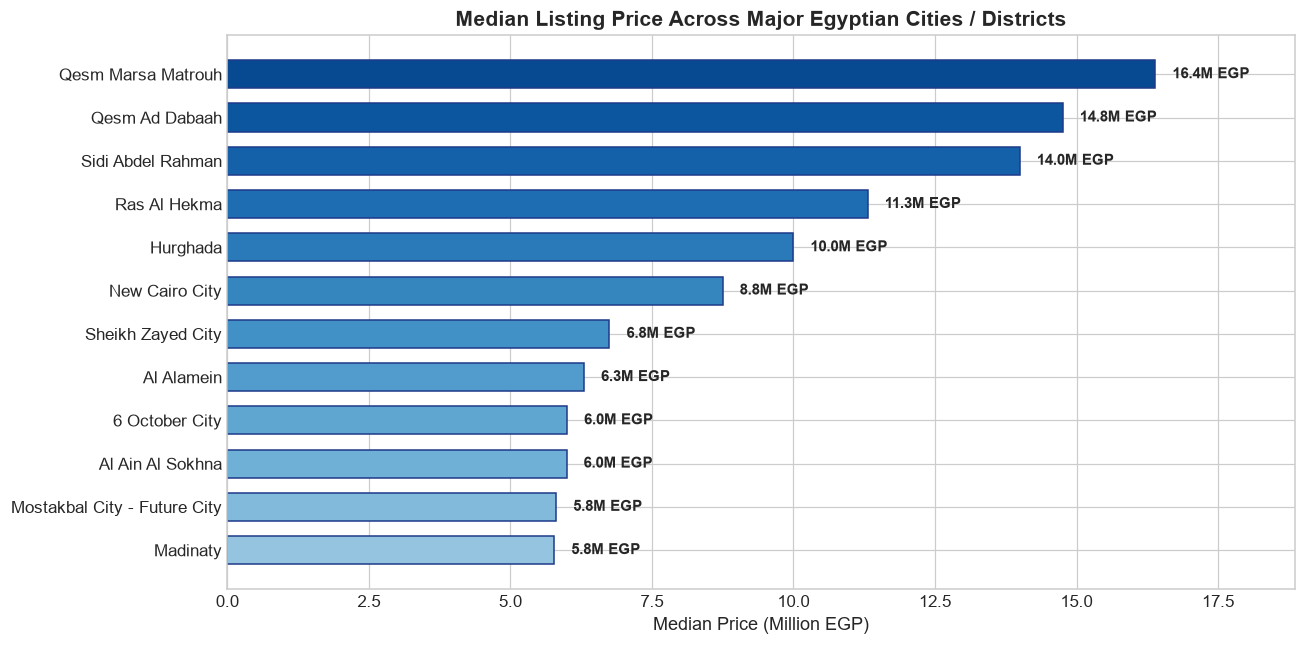

In [7]:
# Plot 3: Top 10 Locations/Cities by Median Price
plt.figure(figsize=(12, 6))

top_cities = df_clean['city'].value_counts().nlargest(12).index
city_prices = df_clean[df_clean['city'].isin(top_cities)].groupby('city')['price'].median() / 1e6
city_prices = city_prices.sort_values(ascending=True)

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(city_prices)))
bars = plt.barh(city_prices.index, city_prices.values, color=colors, edgecolor='#1E3A8A', height=0.65)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.3, bar.get_y() + bar.get_height()/2, f"{w:.1f}M EGP", va='center', fontsize=10, fontweight='bold')

plt.title("Median Listing Price Across Major Egyptian Cities / Districts", fontsize=14, fontweight='bold')
plt.xlabel("Median Price (Million EGP)", fontsize=12)
plt.xlim(0, max(city_prices.values) * 1.15)
plt.tight_layout()
plt.show()



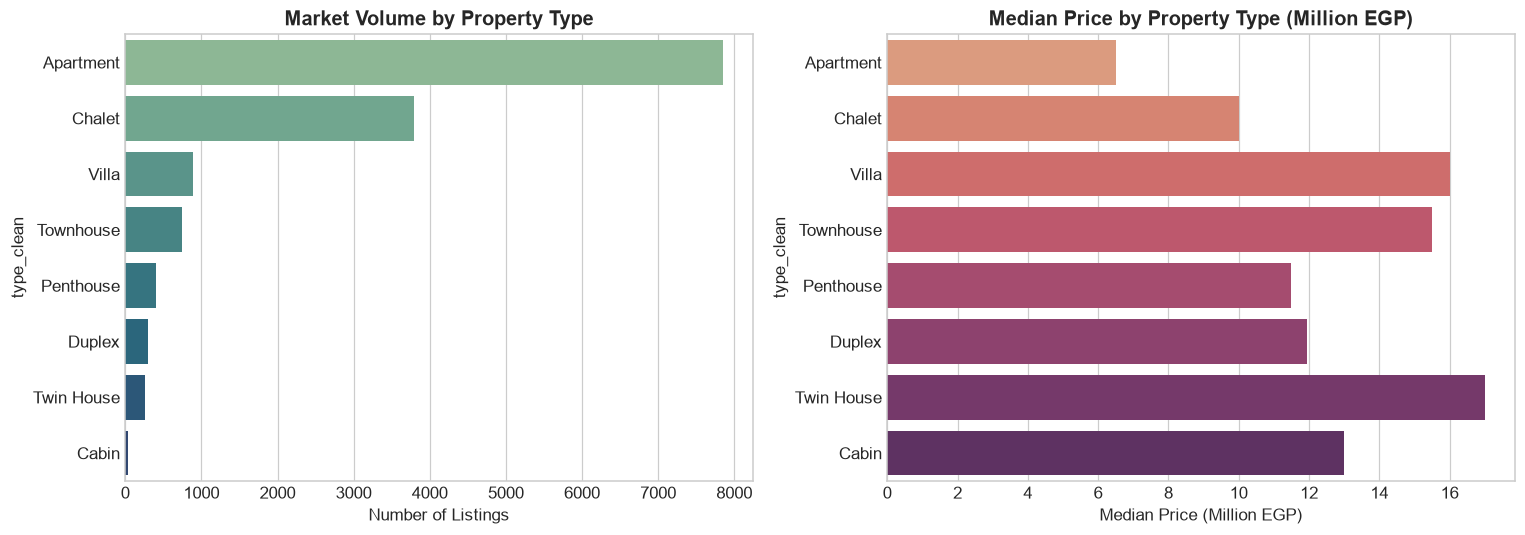

In [8]:
# Plot 4: Property Types Distribution & Median Price
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

type_counts = df_clean['type_clean'].value_counts().nlargest(8)
sns.barplot(x=type_counts.values, y=type_counts.index, palette='crest', ax=ax1)
ax1.set_title("Market Volume by Property Type", fontsize=13, fontweight='bold')
ax1.set_xlabel("Number of Listings")

type_medians = df_clean.groupby('type_clean')['price'].median().loc[type_counts.index] / 1e6
sns.barplot(x=type_medians.values, y=type_medians.index, palette='flare', ax=ax2)
ax2.set_title("Median Price by Property Type (Million EGP)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Median Price (Million EGP)")

plt.tight_layout()
plt.show()



📊 Amenity Premium Table:
        Amenity  Without Amenity (M EGP)  With Amenity (M EGP)  Premium %
   Private Pool                     8.46                   8.2       -3.1
Sea / Lake View                     8.00                   9.7       21.2
         Garden                     8.04                   9.0       12.0
      Furnished                     8.20                  10.5       28.0
 Fully Finished                     7.23                  10.2       41.1



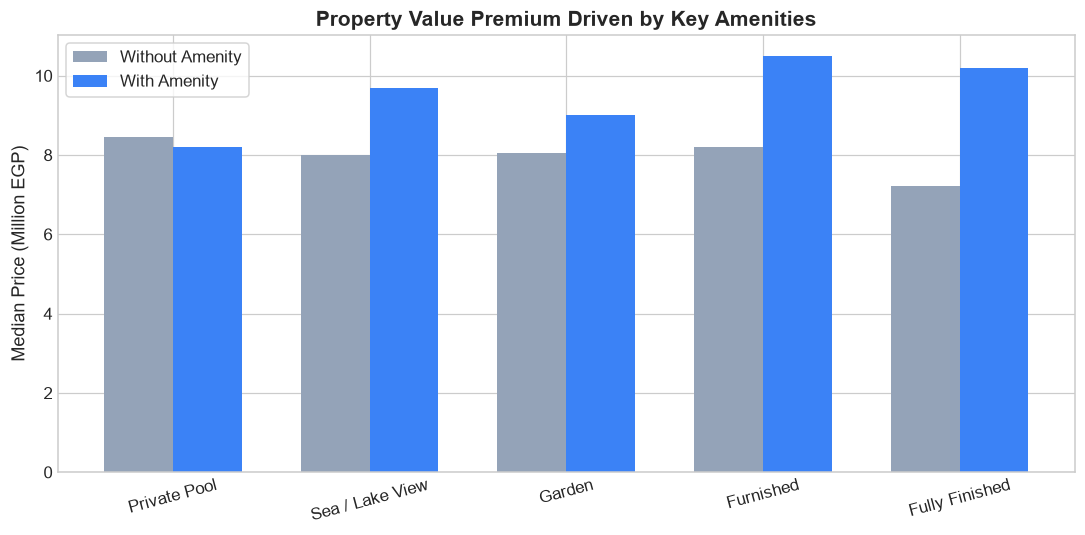

In [9]:
# Plot 5: Impact of Key Amenities on Median Property Price
amenities = ['has_pool', 'has_sea_view', 'has_garden', 'is_furnished', 'is_fully_finished']
amenity_labels = ['Private Pool', 'Sea / Lake View', 'Garden', 'Furnished', 'Fully Finished']

premium_data = []
for col, lbl in zip(amenities, amenity_labels):
    with_am = df_clean[df_clean[col] == 1]['price'].median() / 1e6
    without_am = df_clean[df_clean[col] == 0]['price'].median() / 1e6
    diff_pct = ((with_am - without_am) / without_am) * 100
    premium_data.append({
        'Amenity': lbl,
        'Without Amenity (M EGP)': round(without_am, 2),
        'With Amenity (M EGP)': round(with_am, 2),
        'Premium %': round(diff_pct, 1)
    })

prem_df = pd.DataFrame(premium_data)

plt.figure(figsize=(10, 5))
x = np.arange(len(prem_df))
width = 0.35

plt.bar(x - width/2, prem_df['Without Amenity (M EGP)'], width, label='Without Amenity', color='#94A3B8')
plt.bar(x + width/2, prem_df['With Amenity (M EGP)'], width, label='With Amenity', color='#3B82F6')

plt.xticks(x, prem_df['Amenity'], rotation=15, fontsize=11)
plt.ylabel('Median Price (Million EGP)', fontsize=12)
plt.title('Property Value Premium Driven by Key Amenities', fontsize=14, fontweight='bold')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

print("📊 Amenity Premium Table:")
print(prem_df.to_string(index=False))



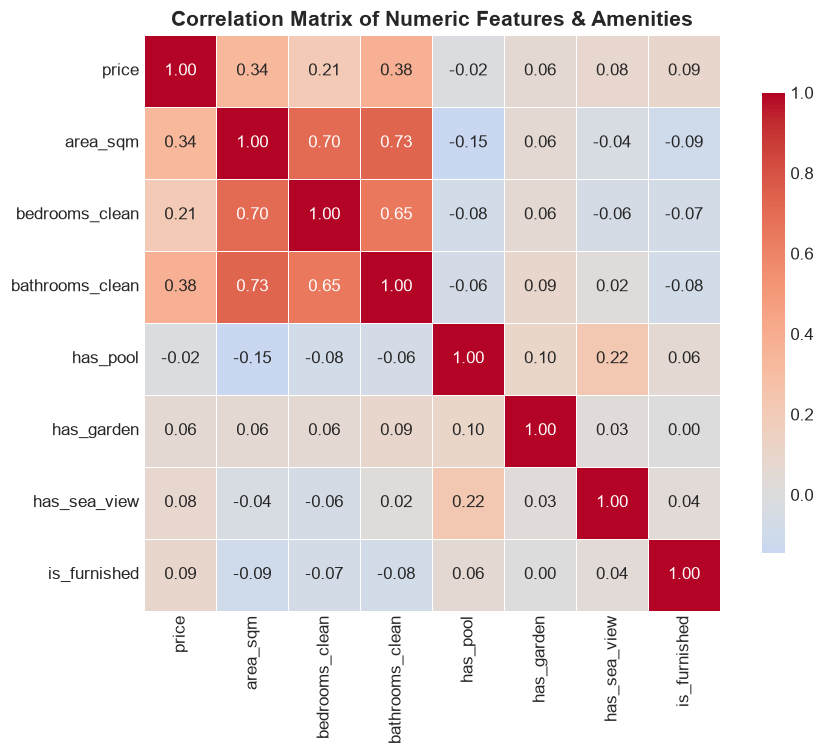

In [10]:
# Plot 6: Correlation Heatmap
num_cols = ['price', 'area_sqm', 'bedrooms_clean', 'bathrooms_clean', 'has_pool', 'has_garden', 'has_sea_view', 'is_furnished']
corr_matrix = df_clean[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title("Correlation Matrix of Numeric Features & Amenities", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



## 5. Machine Learning Modeling & Pipeline Architecture
We prepare a production Scikit-Learn `Pipeline` with:
- **Numerical Pipeline**: Median Imputation + Robust / Standard Scaling
- **Categorical Pipeline**: Frequent Imputation + OneHotEncoding (`handle_unknown='ignore'`)
- **Target Transformation**: `TransformedTargetRegressor` using $\log(1 + y)$ and $\exp(y) - 1$ to normalize skewed real estate prices and avoid negative price predictions.



In [11]:
# Define Features & Target
feature_cols = [
    'area_sqm', 'bedrooms_clean', 'bathrooms_clean',
    'type_clean', 'city', 'governorate', 'compound',
    'has_pool', 'has_garden', 'has_sea_view', 'is_furnished',
    'is_fully_finished', 'has_maid_room', 'payment_method'
]

X = df_clean[feature_cols].copy()
y = df_clean['price'].copy()

# 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"🔹 Training samples : {len(X_train):,}")
print(f"🔹 Testing samples  : {len(X_test):,}")

# Build Preprocessor
num_features = ['area_sqm', 'bedrooms_clean', 'bathrooms_clean', 'has_pool', 'has_garden', 'has_sea_view', 'is_furnished', 'is_fully_finished', 'has_maid_room']
cat_features = ['type_clean', 'city', 'governorate', 'compound', 'payment_method']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_features)
    ]
)

print("✅ Feature Preprocessor configured successfully!")



🔹 Training samples : 11,423
🔹 Testing samples  : 2,856
✅ Feature Preprocessor configured successfully!



In [12]:
# Helper evaluation function
models_results = []

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    print(f"⏳ Training {name}...")
    # Wrap in TransformedTargetRegressor for Log-Price stability
    ttr = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )
    ttr.fit(X_tr, y_tr)
    preds = ttr.predict(X_te)
    
    mae = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2 = r2_score(y_te, preds)
    
    print(f"   ➡️ {name} | MAE: {mae:,.0f} EGP | RMSE: {rmse:,.0f} EGP | R²: {r2:.4f}")
    
    models_results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Fitted_Model': ttr
    })
    return ttr

# Model 1: Baseline Linear Regression
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
evaluate_model("Linear Regression (Baseline)", lr_pipe, X_train, y_train, X_test, y_test)

# Model 2: Random Forest Regressor
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=16, random_state=42, n_jobs=-1))
])
evaluate_model("Random Forest Regressor", rf_pipe, X_train, y_train, X_test, y_test)

# Model 3: LightGBM Regressor
lgbm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=45, random_state=42, verbosity=-1))
])
evaluate_model("LightGBM Regressor", lgbm_pipe, X_train, y_train, X_test, y_test)

# Model 4: XGBoost Regressor
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42))
])
evaluate_model("XGBoost Regressor", xgb_pipe, X_train, y_train, X_test, y_test)



⏳ Training Linear Regression (Baseline)...
   ➡️ Linear Regression (Baseline) | MAE: 3,175,726 EGP | RMSE: 5,392,037 EGP | R²: 0.5059
⏳ Training Random Forest Regressor...
   ➡️ Random Forest Regressor | MAE: 2,855,339 EGP | RMSE: 4,805,736 EGP | R²: 0.6075
⏳ Training LightGBM Regressor...
   ➡️ LightGBM Regressor | MAE: 2,777,060 EGP | RMSE: 4,775,561 EGP | R²: 0.6124
⏳ Training XGBoost Regressor...
   ➡️ XGBoost Regressor | MAE: 2,917,615 EGP | RMSE: 4,992,702 EGP | R²: 0.5764



## 6. Models Comparison & Performance Benchmark
We tabulate and visualize performance across all 4 candidate models.



🏆 Model Benchmark Results:
                       Model MAE (EGP) RMSE (EGP)  R² Score
          LightGBM Regressor 2,777,060  4,775,561    0.6124
     Random Forest Regressor 2,855,339  4,805,736    0.6075
           XGBoost Regressor 2,917,615  4,992,702    0.5764
Linear Regression (Baseline) 3,175,726  5,392,037    0.5059
⭐ Winner Model: LightGBM Regressor with R² = 0.6124 and MAE = 2,777,060 EGP



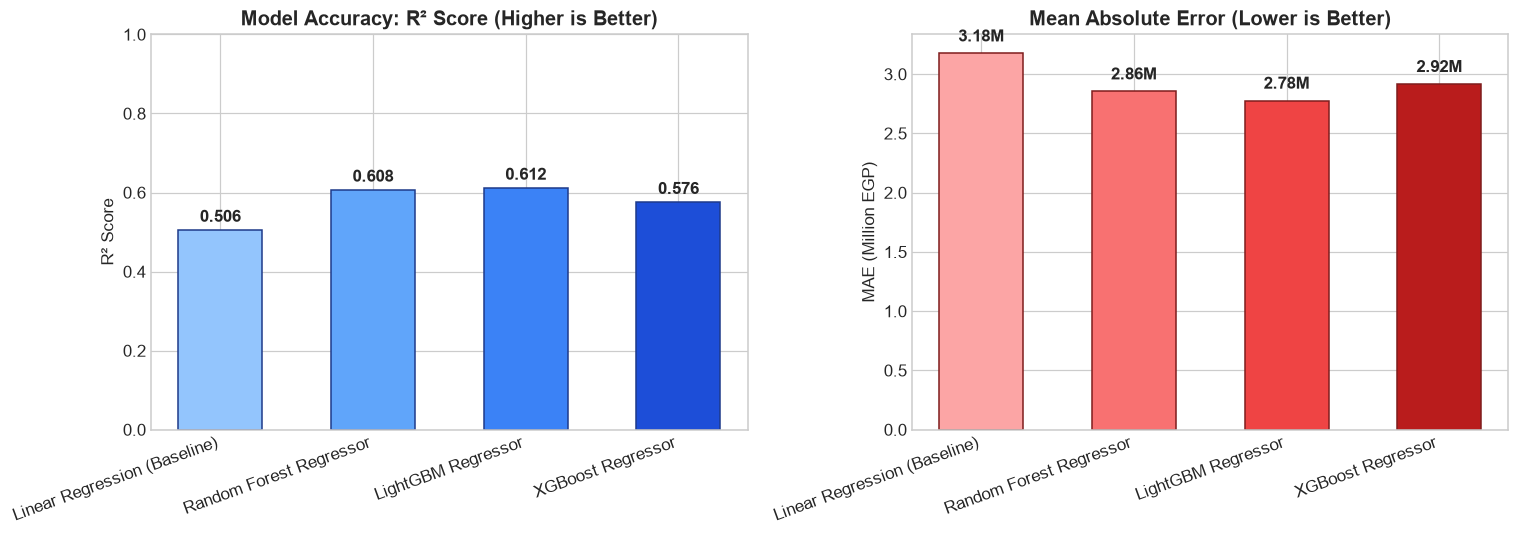

In [13]:
# Create benchmark table
results_df = pd.DataFrame([
    {
        'Model': m['Model'],
        'MAE (EGP)': f"{m['MAE']:,.0f}",
        'RMSE (EGP)': f"{m['RMSE']:,.0f}",
        'R² Score': round(m['R2'], 4)
    }
    for m in models_results
])

# Sort by R2 Score descending
results_df = results_df.sort_values('R² Score', ascending=False)
print("🏆 Model Benchmark Results:")
print(results_df.to_string(index=False))

# Plotting Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

model_names = [m['Model'] for m in models_results]
r2_scores = [m['R2'] for m in models_results]
mae_vals = [m['MAE'] / 1e6 for m in models_results]

# R2 Plot
colors_r2 = ['#93C5FD', '#60A5FA', '#3B82F6', '#1D4ED8']
bars1 = ax1.bar(model_names, r2_scores, color=colors_r2, edgecolor='#1E3A8A', width=0.55)
ax1.set_title("Model Accuracy: R² Score (Higher is Better)", fontsize=13, fontweight='bold')
ax1.set_ylabel("R² Score")
ax1.set_ylim(0, 1.0)
ax1.set_xticklabels(model_names, rotation=20, ha='right')
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.3f}", ha='center', fontweight='bold')

# MAE Plot
colors_mae = ['#FCA5A5', '#F87171', '#EF4444', '#B91C1C']
bars2 = ax2.bar(model_names, mae_vals, color=colors_mae, edgecolor='#7F1D1D', width=0.55)
ax2.set_title("Mean Absolute Error (Lower is Better)", fontsize=13, fontweight='bold')
ax2.set_ylabel("MAE (Million EGP)")
ax2.set_xticklabels(model_names, rotation=20, ha='right')
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.1, f"{h:.2f}M", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

best_entry = max(models_results, key=lambda x: x['R2'])
print(f"⭐ Winner Model: {best_entry['Model']} with R² = {best_entry['R2']:.4f} and MAE = {best_entry['MAE']:,.0f} EGP")



## 7. Model Serialization & Production Export
We export the winning model pipeline and training metadata into `backend/app/models/` for consumption by the FastAPI backend.



In [14]:
os.makedirs("backend/app/models", exist_ok=True)

# Select best model
best_entry = max(models_results, key=lambda x: x['R2'])
best_pipeline = best_entry['Fitted_Model']

# Save model artifact
model_path = "backend/app/models/best_model.pkl"
joblib.dump(best_pipeline, model_path)

# Prepare metadata & options for frontend dropdowns
cities_list = sorted([str(c) for c in df_clean['city'].unique() if pd.notna(c) and c != 'Unknown'])
govs_list = sorted([str(g) for g in df_clean['governorate'].unique() if pd.notna(g) and g != 'Unknown'])
types_list = sorted([str(t) for t in df_clean['type_clean'].unique() if pd.notna(t)])
compounds_list = sorted([str(cp) for cp in df_clean['compound'].unique() if pd.notna(cp) and cp not in ['Other', 'Unknown']])

metadata = {
    'best_model': best_entry['Model'],
    'r2_score': round(best_entry['R2'], 4),
    'mae': round(best_entry['MAE'], 2),
    'rmse': round(best_entry['RMSE'], 2),
    'models_comparison': [
        {
            'model': m['Model'],
            'r2': round(m['R2'], 4),
            'mae': round(m['MAE'], 2),
            'rmse': round(m['RMSE'], 2)
        }
        for m in models_results
    ],
    'options': {
        'types': types_list,
        'cities': cities_list,
        'governorates': govs_list,
        'compounds': compounds_list[:60],
        'payment_methods': ['Cash', 'Installments']
    },
    'dataset_stats': {
        'total_listings': len(df_clean),
        'median_price': float(df_clean['price'].median()),
        'mean_price': float(df_clean['price'].mean()),
        'median_area': float(df_clean['area_sqm'].median()),
        'cities_count': len(cities_list)
    }
}

metrics_path = "backend/app/models/model_metrics.json"
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"💾 Production Model saved to: {model_path}")
print(f"📄 Metadata & Options saved to: {metrics_path}")



💾 Production Model saved to: backend/app/models/best_model.pkl
📄 Metadata & Options saved to: backend/app/models/model_metrics.json



## 8. Real-World Model Verification & Sanity Checks
We load the exported `.pkl` artifact from disk and simulate 3 live prediction requests across different Egyptian property segments.



In [15]:
# Reload the serialized model
loaded_pipeline = joblib.load("backend/app/models/best_model.pkl")

# Test scenarios
test_cases = pd.DataFrame([
    {
        'area_sqm': 140.0,
        'bedrooms_clean': 3.0,
        'bathrooms_clean': 2.0,
        'type_clean': 'Apartment',
        'city': 'Nasr City',
        'governorate': 'Cairo',
        'compound': 'Other',
        'has_pool': 0,
        'has_garden': 0,
        'has_sea_view': 0,
        'is_furnished': 0,
        'is_fully_finished': 1,
        'has_maid_room': 0,
        'payment_method': 'Cash'
    },
    {
        'area_sqm': 210.0,
        'bedrooms_clean': 3.0,
        'bathrooms_clean': 3.0,
        'type_clean': 'Duplex',
        'city': 'New Cairo City',
        'governorate': 'Cairo',
        'compound': 'Mivida',
        'has_pool': 0,
        'has_garden': 1,
        'has_sea_view': 0,
        'is_furnished': 0,
        'is_fully_finished': 1,
        'has_maid_room': 1,
        'payment_method': 'Installments'
    },
    {
        'area_sqm': 450.0,
        'bedrooms_clean': 5.0,
        'bathrooms_clean': 5.0,
        'type_clean': 'Villa',
        'city': 'Sheikh Zayed City',
        'governorate': 'Giza',
        'compound': 'Allegria',
        'has_pool': 1,
        'has_garden': 1,
        'has_sea_view': 0,
        'is_furnished': 1,
        'is_fully_finished': 1,
        'has_maid_room': 1,
        'payment_method': 'Cash'
    }
])

predicted_prices = loaded_pipeline.predict(test_cases)

print("🔮 Model Sanity Check & Sample Predictions:")
print("=" * 70)
profiles = [
    "1. Middle-income Family Apartment (Nasr City, Cairo)",
    "2. Luxury Compound Duplex with Garden (New Cairo City)",
    "3. High-End Standalone Villa with Pool (Sheikh Zayed, Giza)"
]

for prof, row, pred in zip(profiles, test_cases.to_dict('records'), predicted_prices):
    print(f"\n🏢 Profile: {prof}")
    print(f"   • Specs: {row['type_clean']} | {row['area_sqm']} m² | {int(row['bedrooms_clean'])} Bed, {int(row['bathrooms_clean'])} Bath")
    print(f"   • Location: {row['compound']}, {row['city']}, {row['governorate']}")
    print(f"   💰 Predicted Valuation: {pred:,.0f} EGP ({pred/1e6:.2f} Million EGP)")

print("\n✅ All tests passed! The model is verified and ready for deployment.")



🔮 Model Sanity Check & Sample Predictions:

🏢 Profile: 1. Middle-income Family Apartment (Nasr City, Cairo)
   • Specs: Apartment | 140.0 m² | 3 Bed, 2 Bath
   • Location: Other, Nasr City, Cairo
   💰 Predicted Valuation: 3,047,523 EGP (3.05 Million EGP)

🏢 Profile: 2. Luxury Compound Duplex with Garden (New Cairo City)
   • Specs: Duplex | 210.0 m² | 3 Bed, 3 Bath
   • Location: Mivida, New Cairo City, Cairo
   💰 Predicted Valuation: 10,390,415 EGP (10.39 Million EGP)

🏢 Profile: 3. High-End Standalone Villa with Pool (Sheikh Zayed, Giza)
   • Specs: Villa | 450.0 m² | 5 Bed, 5 Bath
   • Location: Allegria, Sheikh Zayed City, Giza
   💰 Predicted Valuation: 7,370,609 EGP (7.37 Million EGP)

✅ All tests passed! The model is verified and ready for deployment.

